# INTRODUCTION

The submergence of Titanic is one of the horrible accident. Although all people belive that this ship cannot sinking, Titanic go down. This accident cause dead of 1502 passengers and crew.

<font color='blue'>
      
      
Content:

1. [Load and Check Data](#1)
1. [Variable Description](#2)
1. [Univariate Variable Analysis](#3)
      * [Categorical Variable](#4)
      * [Numerical Variable](#5)
1. [Basic Data Analysis](#6)
1. [Outlier Detection](#7)
1. [Missing Value](#8)
    * [Find Missing Value](#9)
    * [Fill Missing Value](#10)
1. [Visualization](#11)
    * [Correlation Between SibSp--Parch--Age--Fare--Survived](#12)
    * [SibSp--Survived](#13)
    * [Parch--Survived](#14)
    * [Pclass--Survived](#15)
    * [Age--Survived](#16)
    * [Pclass-Age--Survived](#17)
    * [Embarked -- Sex -- Pclass -- Survived](#18)
    * [Embarked -- Sex -- Fare -- Survived](#19)
    * [Fill Missing: Age Feature](#20)
1. [Feature Engineering](#21)
    * [Name--Title](#22)
    * [Family Size](#23)
    * [Embarked](#24)
    * [Ticket](#25)
    * [Pclass](#26)
    * [Sex](#27)
    * [Drop Passenger ID and Cabin](#28)
1. [Modelling](#29)
    * [Train - Test Split](#30)
    * [Simple Logistic Regression](#31)
    * [Hyperparameter Tuning -- Grid Search -- Cross Validation](#32)
    * [Ensemble Modeling](#33)
    * [Modeling: Prediction and Submission](#34)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

<a id="1"></a>
## Load and Check Data

In [3]:
train_df=pd.read_csv("/kaggle/input/titanic/train.csv")
test_df=pd.read_csv("/kaggle/input/titanic/test.csv")
test_PassengerId= test_df["PassengerId"]

In [4]:
train_df.columns
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<a id="2"></a>

## Variable Description


1. PassengerId: Specific ID number for each passenger
1.    Survived: Passenger alive(1) or died(0)
1.    Pclass: Passenger class
1.    Name: Name of passengers
1.    Sex: Gender of passengers
1.    Age: Age of passengers
1.    Sibsp: Number of siblins/spouses
1.    Parch: Number of parents/children
1. Ticket: Ticket number
1.    Fare: Cost of ticket
1. Cabin: Category of cabin
1. Embarked: Harbour where passengers embarked 
(C=Cherbourg, Q=Queenstown, S=Southampton)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* float64(2): Age and Fare
* int64(5): PassengerId,Survived,Pclass,SibSp and Parch
* object(5): Name,Sex,Ticket,Cabin and Embarked

<a id="3"></a>

## Univariate Variable Analysis
* Categorical Variable: Survived,Sex,Pclass,Embarked,Cabin,Name,Ticket,Sibsp and Parch
* Numerical Variable: Fare,Age and Passenger

<a id="4"></a>

### Categorical Variable 


In [7]:
def bar_plot(variable):
    """
         input: variable ex:"Sex"
         output: bar plot & value count
    """
    #get feature
    var=train_df[variable]
    #count number of categorical variable
    varValue= var.value_counts()
    #visulation
    plt.figure(figsize=(9,3))
    plt.bar(varValue.index,varValue)
    plt.xticks(varValue.index,varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))
    

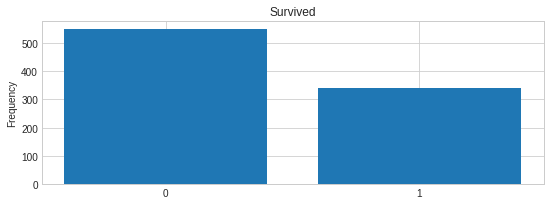

Survived: 
 0    549
1    342
Name: Survived, dtype: int64


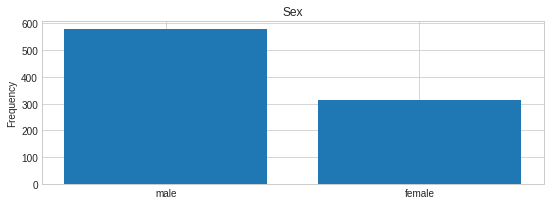

Sex: 
 male      577
female    314
Name: Sex, dtype: int64


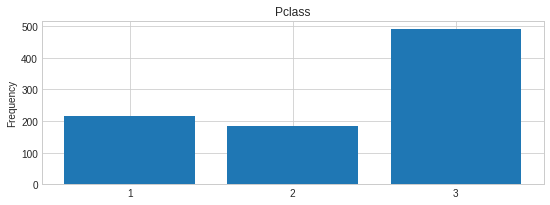

Pclass: 
 3    491
1    216
2    184
Name: Pclass, dtype: int64


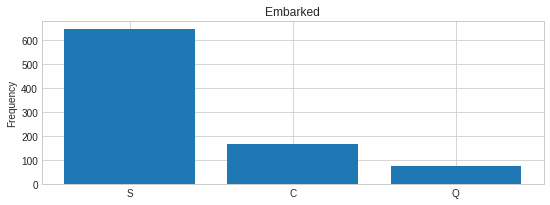

Embarked: 
 S    644
C    168
Q     77
Name: Embarked, dtype: int64


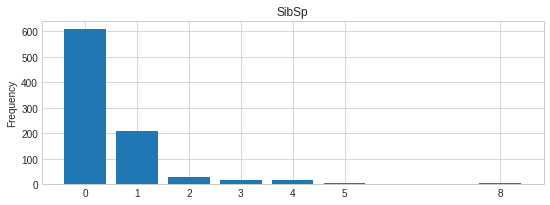

SibSp: 
 0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64


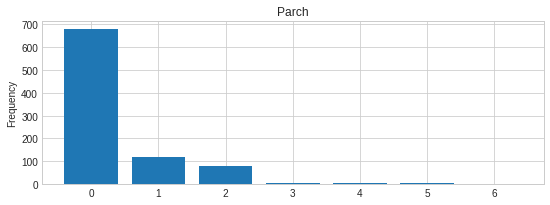

Parch: 
 0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64


In [8]:
category1=["Survived","Sex","Pclass","Embarked","SibSp","Parch"]
for c in category1:
    bar_plot(c)


In [9]:
category2=["Cabin","Name","Ticket"]
for c in category2:
    print("{} \n".format(train_df[c].value_counts()))

B96 B98        4
C23 C25 C27    4
G6             4
F2             3
D              3
              ..
B41            1
E58            1
D46            1
D49            1
C70            1
Name: Cabin, Length: 147, dtype: int64 

Morley, Mr. Henry Samuel ("Mr Henry Marshall")    1
Keane, Miss. Nora A                               1
Chaffee, Mr. Herbert Fuller                       1
Bateman, Rev. Robert James                        1
Long, Mr. Milton Clyde                            1
                                                 ..
Jensen, Mr. Hans Peder                            1
Osen, Mr. Olaf Elon                               1
Thayer, Mr. John Borland Jr                       1
Lulic, Mr. Nikola                                 1
Meyer, Mr. August                                 1
Name: Name, Length: 891, dtype: int64 

347082              7
CA. 2343            7
1601                7
3101295             6
CA 2144             6
                   ..
365226              1
349236

<a id="5"></a>
### Numerical Variable

In [10]:
def plot_hist(variable):
    plt.figure(figsize=(9,3))
    plt.hist(train_df[variable])
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

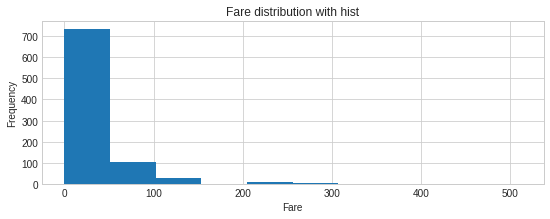

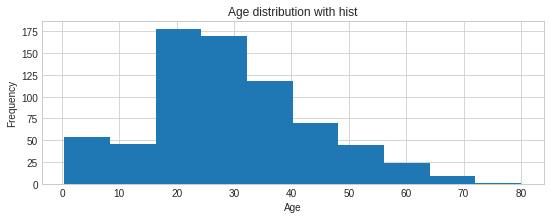

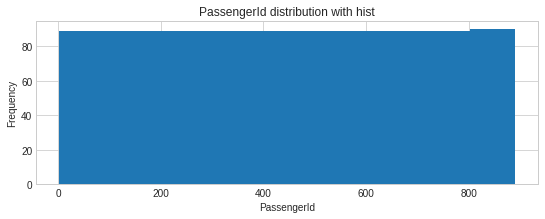

In [11]:
numericVar=["Fare","Age","PassengerId"]
for n in numericVar:
    plot_hist(n)


<a id="6"></a>
## Basic Data Analysis
* Pclass-Survived
* Sex-Survived
* SibSp-Survived
* Parch-Survived

In [12]:
#Pclass VS Survived
train_df[["Pclass","Survived"]].groupby(["Pclass"], as_index=False).mean().sort_values(by="Survived",ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [13]:
#Sex VS Survived
train_df[["Sex","Survived"]].groupby(["Sex"], as_index=False).mean().sort_values(by="Survived",ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [14]:
#SibSp VS Survived
train_df[["SibSp","Survived"]].groupby(["SibSp"], as_index=False).mean().sort_values(by="Survived",ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [15]:
#Parch VS Survived
train_df[["Parch","Survived"]].groupby(["Parch"], as_index=False).mean().sort_values(by="Survived",ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


<a id="7"></a>

## Outlier Detection

In [16]:
def detect_outliers(df,features):
    outlier_indices=[]
    
    for c in features:
        #1st Quartile:
        Q1=np.percentile(df[c],25)
        #3rd Quartile:
        Q3=np.percentile(df[c],25)
        #IQR:
        IQR=Q3-Q1
        #Outlier Step:
        outlier_step=IQR*1.5
        #Detect Outlier and Their İndices
        outlier_list_col=df[(df[c]<Q1-outlier_step) | (df[c]>Q3+outlier_step)].index
        #Store Indeces
        outlier_indices.extend(outlier_list_col)
    outlier_indices=Counter(outlier_indices)
    multiplt_outliers=list(i for i , v in outlier_indices.items() if v>2)
    return multiplt_outliers
        

In [17]:
train_df.loc[detect_outliers(train_df,["Age","SibSp","Parch","Fare"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S


In [18]:
#Drop Outliers
train_df=train_df.drop(detect_outliers(train_df,["Age","SibSp","Parch","Fare"]),axis=0).reset_index(drop=True)

<a id="8"></a>

## Missing Value
* Find Missing Value
* Fill Missing Value

In [19]:
train_df_len=len(train_df)
train_df=pd.concat([train_df,test_df],axis=0).reset_index(drop=True)

In [20]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<a id="9"></a>

### Find Missing Value

In [21]:
train_df.columns[train_df.isnull().any()]

Index(['Survived', 'Age', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [22]:
train_df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age            247
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          903
Embarked         2
dtype: int64

<a id="10"></a>

### Fill Missing Value
* Embarked has 2 missing value
* Fare has only 1

In [23]:
train_df[train_df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
50,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
697,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


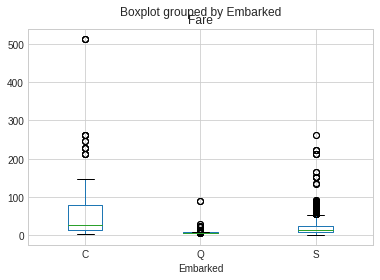

In [24]:
train_df.boxplot(column="Fare",by="Embarked")
plt.show()

In [25]:
train_df["Embarked"]=train_df["Embarked"].fillna("C")
train_df[train_df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [26]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
901,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [27]:
np.mean(train_df[train_df["Pclass"]==3]["Fare"])

11.151679040000008

In [28]:
train_df["Fare"]=train_df["Fare"].fillna(np.mean(train_df[train_df["Pclass"]==3]["Fare"]))

In [29]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


<a id="11"></a>

# Visualization

<a id="12"></a>
### Correlation Between SibSp--Parch--Age--Fare--Survived

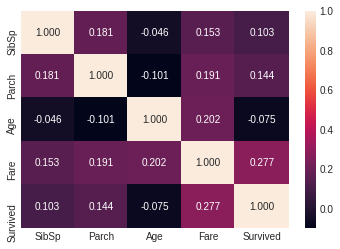

In [30]:
list1=["SibSp" ,"Parch", "Age", "Fare", "Survived"]
sns.heatmap(train_df[list1].corr(),annot=True, fmt='.3f')
plt.show()

Fare feature seems to have correlation with Survived feature (0.277)

<a id="13"></a>
### SibSp--Survived

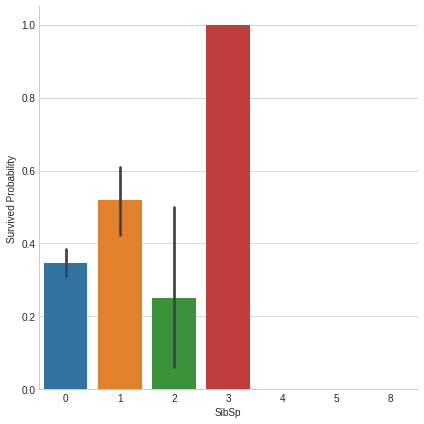

In [31]:
g=sns.factorplot(x="SibSp",y="Survived",data=train_df,kind='bar',size=6)
g.set_ylabels("Survived Probability")
plt.show()

* Having a lot of SibSp have less chance to survive
* If SibSp==0,1 or 2 passenger has more chance to survive

<a id="14"></a>
### Parch--Survived

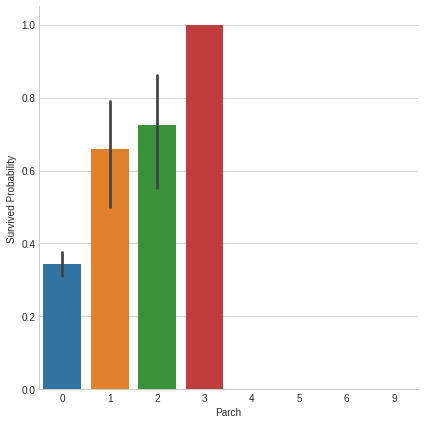

In [32]:
g=sns.factorplot(x="Parch",y="Survived",kind='bar',data=train_df,size=6)
g.set_ylabels("Survived Probability")
plt.show()

* Small families have more chance to survive.
* SibSp and Parch can be used for new feature extraction with th=3

<a id="15"></a>
### Pclass--Survived

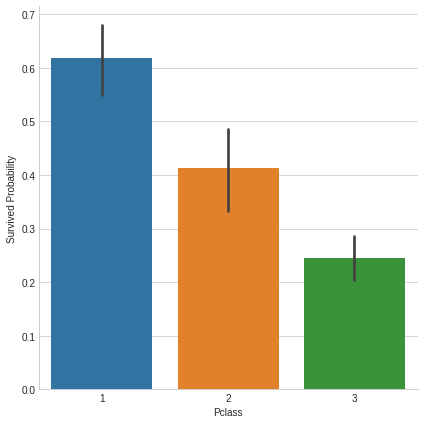

In [33]:
g=sns.factorplot(x="Pclass",y="Survived",data=train_df,kind='bar',size=6)
g.set_ylabels("Survived Probability")
plt.show()

<a id="16"></a>

### Age--Survived

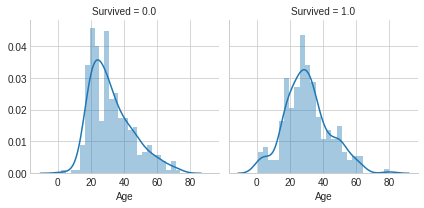

In [34]:
g=sns.FacetGrid(train_df,col="Survived")
g.map(sns.distplot,"Age",bins=25)
plt.show()

* When Age<=10 has a high survival rate
* Oldest passengers (80) survived

<a id="17"></a>
### Pclass-Age--Survived

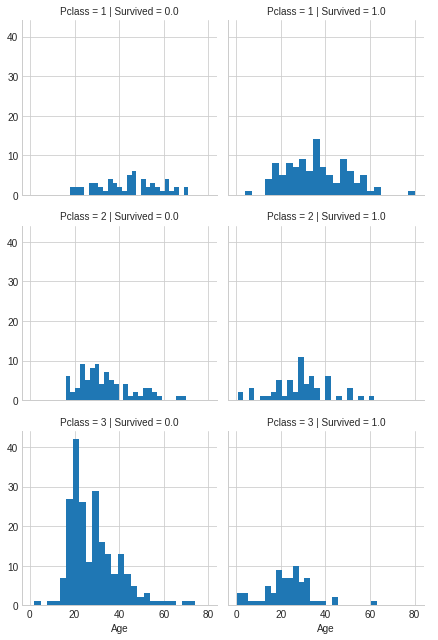

In [35]:
g=sns.FacetGrid(train_df,col="Survived",row="Pclass")
g.map(plt.hist,"Age",bins=25)
g.add_legend()
plt.show()

<a id="18"></a>
### Embarked -- Sex -- Pclass -- Survived

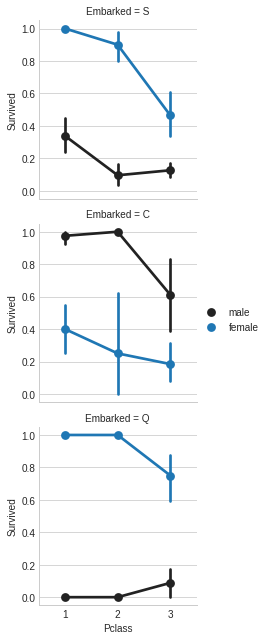

In [36]:
g=sns.FacetGrid(train_df,row="Embarked")
g.map(sns.pointplot,"Pclass","Survived","Sex")
g.add_legend()
plt.show()

<a id="19"></a>
### Embarked -- Sex -- Fare -- Survived

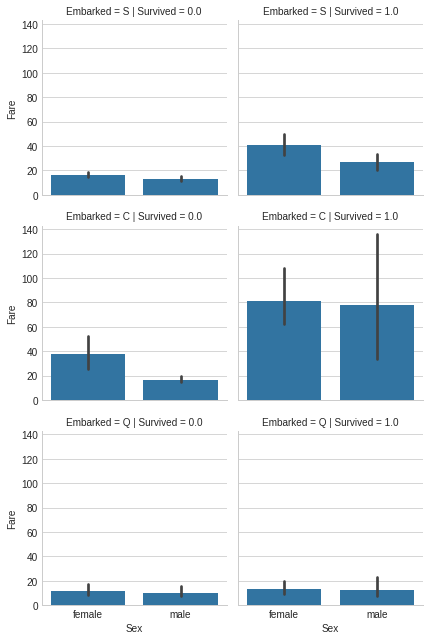

In [37]:
g=sns.FacetGrid(train_df,col="Survived",row="Embarked")
g.map(sns.barplot,"Sex","Fare")
g.add_legend()
plt.show()

<a id="20"></a>
## Fill Missing: Age Feature

In [38]:
train_df[train_df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
13,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
15,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
20,27,0.0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
21,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
1157,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
1159,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
1162,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1165,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Lets check Can we use Sex feature for fill Age feature

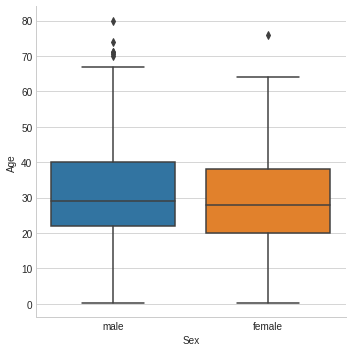

In [39]:
sns.factorplot(x="Sex",y="Age",data=train_df,kind="box")
plt.show()

Sex feature not informative for Age. Their median score are close each other

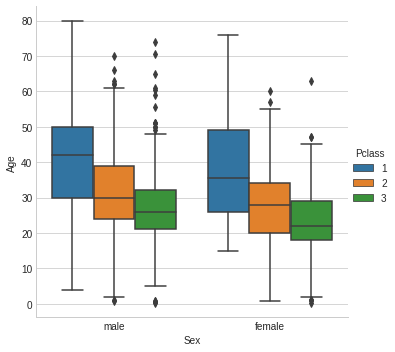

In [40]:
sns.factorplot(x="Sex",y="Age",hue="Pclass",data=train_df,kind="box")
plt.show()

Passengers in 1st class are older than 2nd class and Passenger in 2nd class are older than 3rd class

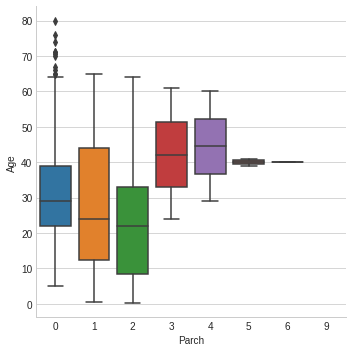

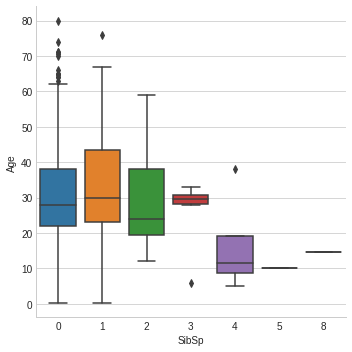

In [41]:
sns.factorplot(x="Parch",y="Age",data=train_df,kind="box")
sns.factorplot(x="SibSp",y="Age",data=train_df,kind="box")
plt.show()

In [42]:
train_df["Sex"]=[1 if i=="male" else 0 for i in train_df["Sex"]]

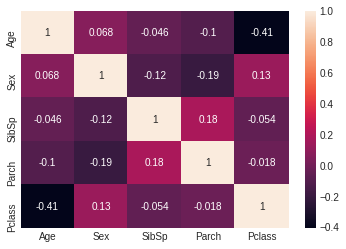

In [43]:
sns.heatmap(train_df[["Age","Sex","SibSp","Parch","Pclass"]].corr(),annot=True)
plt.show()

Age is correlated with Parch, SibSp and Pclass but not correlated with Sex

In [44]:
index_nan_age=list(train_df["Age"][train_df["Age"].isnull()].index)
for i in index_nan_age:
    age_pred = train_df["Age"][((train_df["SibSp"] == train_df.iloc[i]["SibSp"]) &(train_df["Parch"] == train_df.iloc[i]["Parch"])& (train_df["Pclass"] == train_df.iloc[i]["Pclass"]))].median()
    age_med=train_df["Age"].median()
    if not np.isnan(age_pred):
        train_df["Age"].iloc[i]=age_pred
    else:
        train_df["Age"].iloc[i]=age_med

        

In [45]:
train_df[train_df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


<a id="21"></a>
# Feature Engineering

<a id="22"></a>
## Name--Title


In [46]:
train_df["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
8                  Nasser, Mrs. Nicholas (Adele Achem)
9                             Bonnell, Miss. Elizabeth
Name: Name, dtype: object

In [47]:
name=train_df["Name"]
train_df["Title"]=[i.split(".")[0].split(",")[-1].strip() for i in name]
train_df["Title"].head(10)

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
5      Mr
6      Mr
7     Mrs
8     Mrs
9    Miss
Name: Title, dtype: object

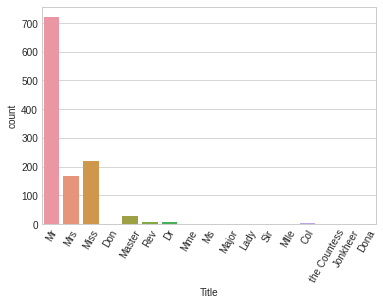

In [48]:
sns.countplot(x="Title",data=train_df)
plt.xticks(rotation=60)
plt.show()

In [49]:
# Convert to Categorical
train_df["Title"] = train_df["Title"].replace(["Lady","the Countess","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],"other")
train_df["Title"] = [0 if i == "Master" else 1 if i == "Miss" or i == "Ms" or i == "Mlle" or i == "Mrs" else 2 if i == "Mr" else 3 for i in train_df["Title"]]
train_df["Title"].head(20)

0     2
1     1
2     1
3     1
4     2
5     2
6     2
7     1
8     1
9     1
10    2
11    1
12    1
13    2
14    1
15    1
16    2
17    2
18    1
19    2
Name: Title, dtype: int64

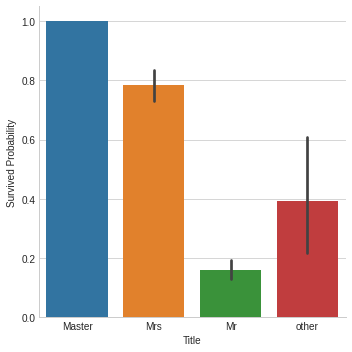

In [50]:
g=sns.factorplot(x="Title",y="Survived",data=train_df,kind="bar")
g.set_xticklabels(["Master","Mrs","Mr","other"])
g.set_ylabels("Survived Probability")
plt.show()

We create a new feature using Name feature. This new feature's name is Title. So we dont need Name feature anymore

In [51]:
train_df.drop(labels=["Name"],axis=1,inplace=True)

In [52]:
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,2


In [53]:
train_df=pd.get_dummies(train_df,columns=["Title"])
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0


<a id="23"></a>
## Family Size

In [54]:
train_df["Fsize"]=train_df["SibSp"]+train_df["Parch"]+1

In [55]:
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1


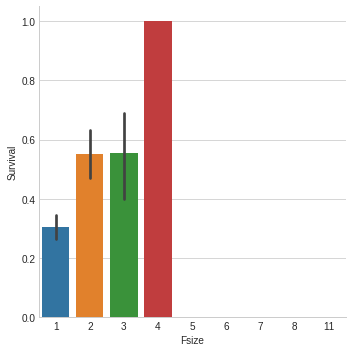

In [56]:
g=sns.factorplot(x="Fsize",y="Survived",data=train_df,kind="bar")
g.set_ylabels("Survival")
plt.show()

In [57]:
train_df["family_size"] = [1 if i < 5 else 0 for i in train_df["Fsize"]]

In [58]:
train_df.head(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize,family_size
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1,1
5,6,0.0,3,1,25.0,0,0,330877,8.4583,NaN,Q,0,0,1,0,1,1
6,7,0.0,1,1,54.0,0,0,17463,51.8625,E46,S,0,0,1,0,1,1
7,9,1.0,3,0,27.0,0,2,347742,11.1333,NaN,S,0,1,0,0,3,1
8,10,1.0,2,0,14.0,1,0,237736,30.0708,NaN,C,0,1,0,0,2,1
9,12,1.0,1,0,58.0,0,0,113783,26.5500,C103,S,0,1,0,0,1,1


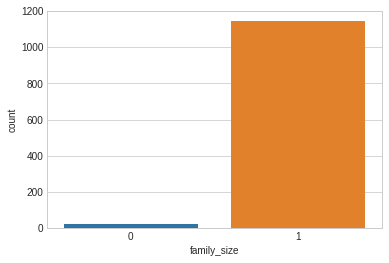

In [59]:
sns.countplot(x="family_size",data=train_df)
plt.show()

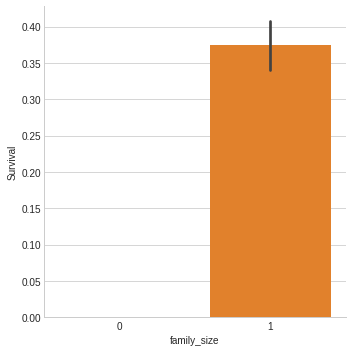

In [60]:
g=sns.factorplot(x="family_size",y="Survived",data=train_df,kind="bar")
g.set_ylabels("Survival")
plt.show()

Small familes have more chance to survive than large families.

In [61]:
train_df=pd.get_dummies(train_df,columns=["family_size"])
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,family_size_1
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2,0,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2,0,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2,0,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1,0,1


<a id="24"></a>
## Embarked

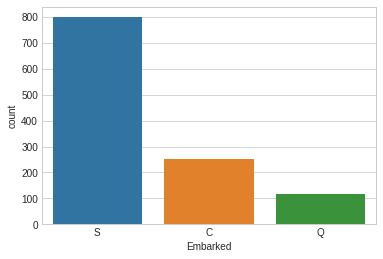

In [62]:
sns.countplot(x="Embarked",data=train_df)
plt.show()

In [63]:
train_df=pd.get_dummies(train_df,columns=["Embarked"])
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,family_size_1,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1,0,2,0,1,0,0,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,0,1,0,0,2,0,1,1,0,0
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,0,0,1,0,1,0,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,0,1,0,0,2,0,1,0,0,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,0,0,1,0,1,0,1,0,0,1


<a id="25"></a>
## Ticket

In [64]:
train_df["Ticket"].head(20)

0            A/5 21171
1             PC 17599
2     STON/O2. 3101282
3               113803
4               373450
5               330877
6                17463
7               347742
8               237736
9               113783
10           A/5. 2151
11              350406
12              248706
13              244373
14              345763
15                2649
16              239865
17              248698
18              330923
19              113788
Name: Ticket, dtype: object

In [65]:
tickets=[]
for i in list(train_df.Ticket):
    if not i.isdigit():
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0]) 
    else:
        tickets.append("x")
train_df["Ticket"]=tickets

In [66]:
train_df["Ticket"].head(20)

0         A5
1         PC
2     STONO2
3          x
4          x
5          x
6          x
7          x
8          x
9          x
10        A5
11         x
12         x
13         x
14         x
15         x
16         x
17         x
18         x
19         x
Name: Ticket, dtype: object

In [67]:
train_df=pd.get_dummies(train_df,columns=["Ticket"],prefix="T")
train_df.head(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title_0,...,T_SOTONO2,T_SOTONOQ,T_SP,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x
0,1,0.0,3,1,22.0,1,0,7.2500,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1.0,1,0,38.0,1,0,71.2833,C85,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1.0,3,0,26.0,0,0,7.9250,NaN,0,...,0,0,0,0,1,0,0,0,0,0
3,4,1.0,1,0,35.0,1,0,53.1000,C123,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0.0,3,1,35.0,0,0,8.0500,NaN,0,...,0,0,0,0,0,0,0,0,0,1
5,6,0.0,3,1,25.0,0,0,8.4583,NaN,0,...,0,0,0,0,0,0,0,0,0,1
6,7,0.0,1,1,54.0,0,0,51.8625,E46,0,...,0,0,0,0,0,0,0,0,0,1
7,9,1.0,3,0,27.0,0,2,11.1333,NaN,0,...,0,0,0,0,0,0,0,0,0,1
8,10,1.0,2,0,14.0,1,0,30.0708,NaN,0,...,0,0,0,0,0,0,0,0,0,1
9,12,1.0,1,0,58.0,0,0,26.5500,C103,0,...,0,0,0,0,0,0,0,0,0,1


<a id="26"></a>
## Pclass

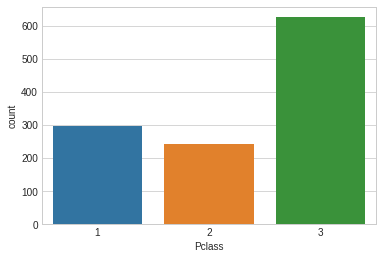

In [68]:
sns.countplot(x="Pclass",data=train_df)
plt.show()

In [69]:
train_df["Pclass"]=train_df["Pclass"].astype("category")
train_df=pd.get_dummies(train_df,columns=["Pclass"])
train_df.head(20)

,PassengerId,Survived,Sex,Age,SibSp,Parch,Fare,Cabin,Title_0,Title_1,...,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3
0,1,0.0,1,22.0,1,0,7.2500,NaN,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1.0,0,38.0,1,0,71.2833,C85,0,1,...,0,0,0,0,0,0,0,1,0,0
2,3,1.0,0,26.0,0,0,7.9250,NaN,0,1,...,0,1,0,0,0,0,0,0,0,1
3,4,1.0,0,35.0,1,0,53.1000,C123,0,1,...,0,0,0,0,0,0,1,1,0,0
4,5,0.0,1,35.0,0,0,8.0500,NaN,0,0,...,0,0,0,0,0,0,1,0,0,1
5,6,0.0,1,25.0,0,0,8.4583,NaN,0,0,...,0,0,0,0,0,0,1,0,0,1
6,7,0.0,1,54.0,0,0,51.8625,E46,0,0,...,0,0,0,0,0,0,1,1,0,0
7,9,1.0,0,27.0,0,2,11.1333,NaN,0,1,...,0,0,0,0,0,0,1,0,0,1
8,10,1.0,0,14.0,1,0,30.0708,NaN,0,1,...,0,0,0,0,0,0,1,0,1,0
9,12,1.0,0,58.0,0,0,26.5500,C103,0,1,...,0,0,0,0,0,0,1,1,0,0


<a id="27"></a>
## Sex


In [70]:
train_df["Sex"]=train_df["Sex"].astype("category")
train_df=pd.get_dummies(train_df,columns=["Sex"])
train_df.head(20)

,PassengerId,Survived,Age,SibSp,Parch,Fare,Cabin,Title_0,Title_1,Title_2,...,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
0,1,0.0,22.0,1,0,7.2500,NaN,0,0,1,...,0,0,0,0,0,0,0,1,0,1
1,2,1.0,38.0,1,0,71.2833,C85,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2,3,1.0,26.0,0,0,7.9250,NaN,0,1,0,...,0,0,0,0,0,0,0,1,1,0
3,4,1.0,35.0,1,0,53.1000,C123,0,1,0,...,0,0,0,0,1,1,0,0,1,0
4,5,0.0,35.0,0,0,8.0500,NaN,0,0,1,...,0,0,0,0,1,0,0,1,0,1
5,6,0.0,25.0,0,0,8.4583,NaN,0,0,1,...,0,0,0,0,1,0,0,1,0,1
6,7,0.0,54.0,0,0,51.8625,E46,0,0,1,...,0,0,0,0,1,1,0,0,0,1
7,9,1.0,27.0,0,2,11.1333,NaN,0,1,0,...,0,0,0,0,1,0,0,1,1,0
8,10,1.0,14.0,1,0,30.0708,NaN,0,1,0,...,0,0,0,0,1,0,1,0,1,0
9,12,1.0,58.0,0,0,26.5500,C103,0,1,0,...,0,0,0,0,1,1,0,0,1,0


<a id="28"></a>
## Drop Passenger ID and Cabin

In [71]:
train_df.drop(labels=["PassengerId","Cabin"],axis=1,inplace=True)

In [72]:
train_df.columns

Index(['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Title_0', 'Title_1',
       'Title_2', 'Title_3', 'Fsize', 'family_size_0', 'family_size_1',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'T_A', 'T_A4', 'T_A5',
       'T_AQ3', 'T_AQ4', 'T_AS', 'T_C', 'T_CA', 'T_CASOTON', 'T_FC', 'T_FCC',
       'T_Fa', 'T_LINE', 'T_LP', 'T_PC', 'T_PP', 'T_PPP', 'T_SC', 'T_SCA3',
       'T_SCA4', 'T_SCAH', 'T_SCOW', 'T_SCPARIS', 'T_SCParis', 'T_SOC',
       'T_SOP', 'T_SOPP', 'T_SOTONO2', 'T_SOTONOQ', 'T_SP', 'T_STONO',
       'T_STONO2', 'T_STONOQ', 'T_SWPP', 'T_WC', 'T_WEP', 'T_x', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Sex_0', 'Sex_1'],
      dtype='object')

<a id="29"></a>

# Modelling

In [73]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

<a id="30"></a>
## Train - Test Split

In [74]:
train_df_len

749

In [75]:
test=train_df[train_df_len:]
test.drop(labels=["Survived"],axis=1,inplace=True)
test.head()

,Age,SibSp,Parch,Fare,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,...,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
749,34.5,0,0,7.8292,0,0,1,0,1,0,...,0,0,0,0,1,0,0,1,0,1
750,47.0,1,0,7.0000,0,1,0,0,2,0,...,0,0,0,0,1,0,0,1,1,0
751,62.0,0,0,9.6875,0,0,1,0,1,0,...,0,0,0,0,1,0,1,0,0,1
752,27.0,0,0,8.6625,0,0,1,0,1,0,...,0,0,0,0,1,0,0,1,0,1
753,22.0,1,1,12.2875,0,1,0,0,3,0,...,0,0,0,0,1,0,0,1,1,0


In [76]:
train=train_df[:train_df_len]
X_train=train.drop(labels=["Survived"],axis=1)
y_train=train["Survived"]
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=0.33,random_state=42)
print("X_train",len(X_train))
print("X_test",len(X_test))
print("y_train",len(y_train))
print("y_test",len(y_test))
print("test",len(test))

X_train 501
X_test 248
y_train 501
y_test 248
test 418


<a id="31"></a>
## Simple Logistic Regression

In [77]:
logreg=LogisticRegression()
logreg.fit(X_train,y_train)
acc_log_train=round(logreg.score(X_train,y_train)*100,2)
acc_log_test=round(logreg.score(X_test,y_test)*100,2)
print("Training Accuracy: % {}".format(acc_log_train))
print("Testing Accuracy: % {}".format(acc_log_test))

Training Accuracy: % 83.23
Testing Accuracy: % 79.84


<a id="32"></a>
## Hyperparameter Tuning -- Grid Search -- Cross Validation

We will compare 5 ML classifier and evaluate Mean Accuracy of each of them by Stratified Cross Validation.

* Decision Tree
* SVM
* Random Forest
* KNN
* Logistic Regression

In [78]:
random_state=42
classifier=[DecisionTreeClassifier(random_state=random_state),
           SVC(random_state=random_state),
           RandomForestClassifier(random_state=random_state),
           LogisticRegression(random_state=random_state),
           KNeighborsClassifier()]

dt_param_grid={"min_samples_split": range(10,500,20),
              "max_depth": range(1,20,2)}

svm_param_grid={"kernel":["rbf"],
               "gamma":[0.001,0.01,0.1,1],
               "C":[1,10,50,100,200,300,1000]}
rf_param_grid={"max_features":[1,3,10],
              "min_samples_split":[2,3,10],
               "min_samples_leaf":[1,3,10],
              "bootstrap":[False],
              "n_estimators":[100,300],
              "criterion":["gini"]}
logreg_param_grid={"C":np.logspace(-3,3,7),
                  "penalty":["l1","l2"]}
knn_param_grid={"n_neighbors":np.linspace(1,19,10,dtype=int).tolist(),
               "weights":["uniform","distance"],
               "metric":["euclidean","manhattan"]}
classifier_param=[dt_param_grid,svm_param_grid,rf_param_grid,logreg_param_grid,knn_param_grid]



In [79]:
cv_result=[]
best_estimators=[]
for i in range(len(classifier)):
    clf=GridSearchCV(classifier[i],param_grid=classifier_param[i],cv=StratifiedKFold(n_splits=10),scoring="accuracy",n_jobs=-1,verbose=1)
    clf.fit(X_train,y_train)
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)
    print(cv_result[i])
    

Fitting 10 folds for each of 250 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 2380 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   10.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8442745098039216
Fitting 10 folds for each of 28 candidates, totalling 280 fits


[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 280 out of 280 | elapsed:    4.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8004313725490197
Fitting 10 folds for each of 54 candidates, totalling 540 fits


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 123 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 140 out of 140 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8244313725490195
Fitting 10 folds for each of 40 candidates, totalling 400 fits


[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.0s


0.7805490196078432


[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    1.9s finished


Text(0.5, 1.0, 'Cross Validation Scores')

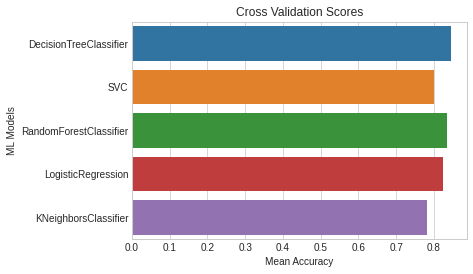

In [80]:
cv_results=pd.DataFrame({"Cross Validation Means":cv_result,"ML Models":["DecisionTreeClassifier","SVC","RandomForestClassifier","LogisticRegression","KNeighborsClassifier"]})
g=sns.barplot("Cross Validation Means","ML Models",data=cv_results)
g.set_xlabel("Mean Accuracy")
g.set_title("Cross Validation Scores")

<a id="33"></a>
## Ensemble Modeling

In [81]:
votingC=VotingClassifier(estimators=[("dt",best_estimators[0]),
                                    ("rfc",best_estimators[2]),
                                    ("lr",best_estimators[3])],
                                    voting="soft",n_jobs=-1)
votingC=votingC.fit(X_train,y_train)
print(accuracy_score(votingC.predict(X_test),y_test))

0.7862903225806451


<a id="34"></a>
## Modeling: Prediction and Submission

In [82]:
test_survived=pd.Series(votingC.predict(test),name="Survived").astype(int)
results=pd.concat([test_PassengerId,test_survived],axis=1)
results.to_csv("titanic.csv",index=False)